# Multi Agents - 고객 지원 챗봇 (초급)

## 개요
LangGraph를 활용하여 여러 에이전트가 협력하는 고객 지원 챗봇을 구현합니다.

## 구성
1. **분류 에이전트**: 고객 문의 유형을 판단 (기술/결제/일반)
2. **기술 지원 에이전트**: 기술 문제 해결
3. **결제 지원 에이전트**: 결제 관련 처리
4. **일반 상담 에이전트**: 일반 문의 응답

## 학습 목표
- 조건부 라우팅 (conditional routing)
- 상태 관리 (state management)
- 여러 에이전트 중 선택적 실행


## 1. LLM 모델 초기화 


In [6]:
from langchain_ollama.chat_models import ChatOllama 

llm = ChatOllama(
    model="gemma3:4b",
    temperature=0.1,
    top_p=1.0,
    keep_alive="5m"
)

## 2. 상태 정의 (State Management)

그래프에서 사용할 상태 구조를 정의합니다. 상태는 모든 노드 간에 공유되며, 각 에이전트가 정보를 추가하거나 수정할 수 있습니다.


In [7]:
from typing import TypedDict

class SupportState(TypedDict):
    """
    고객 지원 챗봇의 상태를 정의하는 클래스
    """
    question: str # 고객의 원본 문의 내용
    category: str # 문의 유형 ("technical", "billing", "general")
    response: str # 최종 응답 메시지



## 3. 에이전트 노드 정의

각 에이전트의 역할과 기능을 정의합니다.


### 3.1 분류 에이전트 (Classifier Agent)

고객의 문의 내용을 분석하여 적절한 지원 유형으로 분류합니다.


In [8]:
from langchain_core.messages import HumanMessage, SystemMessage

def classifier_agent(state: SupportState) -> SupportState:
    """
    고객 문의를 분석하여 적절한 카테고리로 분류하는 에이전트
    """
    question = state["question"]
    
    # LLM을 사용하여 문의 유형 분류
    messages = [
        SystemMessage(content="""
            당신은 고객 문의를 분류하는 전문가입니다.
            고객의 문의를 다음 세 가지 카테고리 중 하나로 분류하세요:

            1. technical - 기술적 문제, 오류, 버그, 기능 작동 문제 등
            2. billing - 결제, 환불, 요금제, 구독 관련 문제
            3. general - 일반 문의, 제품 정보, 사용 방법 등

            반드시 'technical', 'billing', 'general' 중 하나의 단어만 응답하세요."""),
        HumanMessage(content=f"다음 문의를 분류하세요: {question}")
    ]
    
    response = llm.invoke(messages)
    category = response.content.strip().lower()
    
    print(f"[분류 에이전트] 문의 유형: {category}")
    
    return {
        "question": question,
        "category": category,
        "response": ""
    }


In [9]:
# 테스트
test_state = {"question": "로그인이 안됩니다", "category": "", "response": ""}
result = classifier_agent(test_state)
print(f"분류 결과: {result['category']}")

/Users/gyoungwon-cho/dev/github/course_LLM/3. LangChain/2. multi_agents/.venv/lib/python3.13/site-packages/langsmith/client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(
Failed to multipart ingest runs: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=deb86ac4-ec3e-4152-a8a1-6b00e7967c35,id=deb86ac4-ec3e-4152-a8a1-6b00e7967c35


[분류 에이전트] 문의 유형: technical
분류 결과: technical


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=deb86ac4-ec3e-4152-a8a1-6b00e7967c35,id=deb86ac4-ec3e-4152-a8a1-6b00e7967c35
Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=b0ea3fee-b394-4539-866a-6c99689933ba,id=b0ea3fee-b394-4539-866a-6c99689933ba; trace=b0ea3fee-b394-4539-866a-6c99689933ba,id=0ed09ce9-fa35-4dd8-9805-fcd7ffc7b528; trace=b0ea3fee-b394-4539-866a-6c99689933ba,id=5e2fe599-a296-4118-b13d-5d30d1d2320b; trace=b0ea3fee-b394-4539-866a-6c99689933ba,id=5e2fe599-a296-4118-b13d-5d30d1d2320b; trace=b0ea3fee-

### 3.2 기술 지원 에이전트

기술적인 문제를 해결하는 전문 에이전트입니다.


In [10]:
def technical_support_agent(state: SupportState) -> SupportState:
    """
    기술적 문제를 해결하는 에이전트
    """
    question = state["question"]
    
    messages = [
        SystemMessage(content="""
            당신은 기술 지원 전문가입니다.
            고객의 기술적 문제를 친절하고 명확하게 해결해주세요.
            단계별 해결 방법을 제시하고, 가능한 원인을 설명하세요."""),
        HumanMessage(content=question)
    ]
    
    response = llm.invoke(messages)
    answer = response.content
    
    print(f"[기술 지원 에이전트] 응답 생성 완료")
    
    return {
        "question": question,
        "category": state["category"],
        "response": answer
    }


### 3.3 결제 지원 에이전트

결제 및 청구 관련 문제를 처리하는 에이전트입니다.


In [11]:
def billing_support_agent(state: SupportState) -> SupportState:
    """
    결제 및 청구 관련 문제를 처리하는 에이전트
    """
    question = state["question"]
    
    messages = [
        SystemMessage(content="""
            당신은 결제 및 청구 관련 전문 상담원입니다.
            고객의 결제, 환불, 요금제 관련 문의에 정확하고 친절하게 답변하세요.
            필요한 경우 정책과 절차를 안내하세요."""),
        HumanMessage(content=question)
    ]
    
    response = llm.invoke(messages)
    answer = response.content
    
    print(f"[결제 지원 에이전트] 응답 생성 완료")
    
    return {
        "question": question,
        "category": state["category"],
        "response": answer
    }


### 3.4 일반 상담 에이전트

일반적인 문의사항을 처리하는 에이전트입니다.


In [12]:
def general_support_agent(state: SupportState) -> SupportState:
    """
    일반적인 문의사항을 처리하는 에이전트
    """
    question = state["question"]
    
    messages = [
        SystemMessage(content="""
            당신은 친절한 고객 상담원입니다.
            고객의 일반적인 문의에 친절하고 유용한 정보를 제공하세요.
            제품이나 서비스에 대한 설명을 명확하게 전달하세요."""),
        HumanMessage(content=question)
    ]
    
    response = llm.invoke(messages)
    answer = response.content
    
    print(f"[일반 상담 에이전트] 응답 생성 완료")
    
    return {
        "question": question,
        "category": state["category"],
        "response": answer
    }


## 4. 조건부 라우팅 (Conditional Routing)

분류 결과에 따라 적절한 에이전트로 라우팅하는 함수를 정의합니다.


In [13]:
from typing import Literal

def route_question(state: SupportState) -> Literal["technical", "billing", "general"]:
    """
    분류된 카테고리에 따라 적절한 에이전트로 라우팅하는 함수
    """
    category = state["category"]
    
    print(f"[라우터] '{category}' 카테고리로 라우팅")
    
    # 카테고리에 따라 다음 노드 결정
    if category == "technical":
        return "technical"
    elif category == "billing":
        return "billing"
    else:
        return "general"



## 5. 그래프 구성

LangGraph를 사용하여 전체 워크플로우를 구성합니다.

In [14]:
from langgraph.graph import StateGraph, END

# StateGraph 생성
workflow = StateGraph(SupportState)

# 노드 추가
workflow.add_node("classifier", classifier_agent)
workflow.add_node("technical", technical_support_agent)
workflow.add_node("billing", billing_support_agent)
workflow.add_node("general", general_support_agent)

# 시작점 설정
workflow.set_entry_point("classifier")

# 조건부 엣지 추가 (분류 에이전트 -> 라우팅)
workflow.add_conditional_edges(
    "classifier",  # 출발 노드
    route_question,  # 라우팅 함수
    {
        "technical": "technical",  # 기술 지원으로
        "billing": "billing",      # 결제 지원으로
        "general": "general"       # 일반 상담으로
    }
)

# 각 전문 에이전트에서 END로 연결
workflow.add_edge("technical", END)
workflow.add_edge("billing", END)
workflow.add_edge("general", END)

# 그래프 컴파일
app = workflow.compile()


## 6. 그래프 시각화 (선택사항)

그래프의 구조를 시각적으로 확인할 수 있습니다.


```
시작
  |
  v
분류 에이전트
  |
  v
조건부 라우팅
  |
  +-- technical --> 기술 지원 에이전트 --> 종료
  |
  +-- billing --> 결제 지원 에이전트 --> 종료
  |
  +-- general --> 일반 상담 에이전트 --> 종료
```


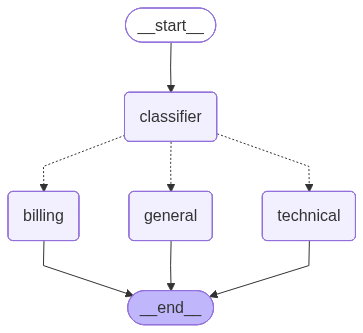

In [15]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            app.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

## 7. 테스트 예제

다양한 문의 유형으로 챗봇을 테스트해봅니다.


### 7.1 테스트 케이스 1: 기술 지원 문의


In [16]:
question1 = "앱이 자꾸 강제 종료됩니다. 어떻게 해야 하나요?"

# 초기 상태 생성
initial_state = {
    "question": question1,
    "category": "",
    "response": ""
}

# 그래프 실행
result = app.invoke(initial_state)

print(f"\n질문: {result['question']}")
print(f"분류: {result['category']}")
print(f"\n응답:\n{result['response']}")
print("=" * 60)


[분류 에이전트] 문의 유형: technical
[라우터] 'technical' 카테고리로 라우팅
[기술 지원 에이전트] 응답 생성 완료

질문: 앱이 자꾸 강제 종료됩니다. 어떻게 해야 하나요?
분류: technical

응답:
안녕하세요! 앱이 계속해서 강제 종료되는 문제로 불편을 겪고 계시다니 정말 안타깝습니다. 하지만 걱정 마세요. 제가 단계별로 해결 방법을 안내해 드리겠습니다. 

**1단계: 문제 재현 확인 및 정보 수집**

*   **어떤 앱에서 발생하나요?** 특정 앱에서만 발생하는지, 아니면 여러 앱에서 모두 발생하는지 확인해주세요.
*   **언제 강제 종료되나요?** 앱을 실행할 때, 특정 기능을 사용할 때, 또는 아무 때나 발생하는지 자세히 살펴보세요.
*   **강제 종료되기 전에 어떤 화면이 보이나요?** 오류 메시지가 나타나거나, 특정 동작을 수행했을 때 발생하는지 확인해주세요.
*   **휴대폰 모델명과 운영체제 버전을 알려주세요.** (예: 삼성 갤럭시 S23, 안드로이드 13)

이 정보들을 알려주시면 문제 해결에 더욱 도움이 될 것입니다.

**2단계: 기본적인 해결 방법**

1.  **휴대폰 재부팅:** 가장 간단하지만 효과적인 방법입니다. 일시적인 오류를 해결할 수 있습니다.
2.  **앱 캐시 및 데이터 삭제:** 앱의 저장 공간을 정리하여 문제를 해결할 수 있습니다.
    *   **안드로이드:** 설정 > 앱 > 해당 앱 선택 > 저장공간 > 캐시 삭제 및 데이터 삭제
    *   **iOS:** 설정 > 앱 > 해당 앱 선택 > 저장공간 > 모든 데이터 삭제 (주의: 데이터 삭제 시 앱 설정이 초기화될 수 있습니다.)
3.  **앱 업데이트 확인:** 앱의 최신 버전으로 업데이트하면 버그 수정 및 성능 개선이 이루어질 수 있습니다.
4.  **백그라운드 앱 제한:** 다른 앱들이 백그라운드에서 실행되는 것을 제한하여 앱의 자원 사용을 줄여보세요.
    *   **안드로이드:** 설정 > 배터리 > 배터리 사

### 7.2 테스트 케이스 2: 결제 지원 문의


In [17]:
question2 = "구독을 취소하고 환불받고 싶습니다."

initial_state = {
    "question": question2,
    "category": "",
    "response": ""
}

result = app.invoke(initial_state)

print(f"\n질문: {result['question']}")
print(f"분류: {result['category']}")
print(f"\n응답:\n{result['response']}")
print("=" * 60)


[분류 에이전트] 문의 유형: billing
[라우터] 'billing' 카테고리로 라우팅
[결제 지원 에이전트] 응답 생성 완료

질문: 구독을 취소하고 환불받고 싶습니다.
분류: billing

응답:
안녕하세요. 고객님, 결제 및 청구 관련 문의에 대해 상담을 도와드리는 전문 상담원입니다. 구독 취소와 환불 관련 문의 주셔서 감사합니다. 

먼저, 어떤 서비스에 대한 구독 취소 및 환불를 원하시는지 여쭤봐도 될까요? 서비스명과 구독 계정 정보 (예: 이메일 주소, 전화번호 등)를 알려주시면 더욱 정확하게 안내해 드릴 수 있습니다.

**일반적인 구독 취소 및 환불 절차는 다음과 같습니다.**

1.  **구독 취소:**
    *   대부분의 서비스는 구독 취소 시 잔여 기간에 해당하는 금액을 환불받으실 수 있습니다.
    *   구독 서비스의 정책에 따라 취소 가능 기간이 다를 수 있으니, 해당 정책을 확인해 주시기 바랍니다.
    *   취소 시점부터 환불 진행까지는 일반적으로 3~7일 정도 소요될 수 있습니다.

2.  **환불 신청:**
    *   구독 취소 후 환불 신청을 진행합니다.
    *   환불 신청 시, 구독 계정 정보와 함께 환불 사유를 입력해야 합니다.
    *   환불 신청 시 필요한 서류 (예: 신분증 사본, 계약서 사본 등)가 있을 수 있으니, 미리 준비해두시는 것이 좋습니다.

3.  **환불 처리:**
    *   환불 신청이 승인되면, 신청하신 금액이 고객님의 결제 계좌로 입금됩니다.
    *   환불 처리에는 일반적으로 3~7일 정도 소요됩니다.

**참고 사항:**

*   **환불 정책:** 서비스마다 환불 정책이 다르므로, 해당 서비스의 환불 정책을 자세히 확인해 주시기 바랍니다.
*   **취소 가능 기간:** 구독 취소 시 환불 가능 여부 및 환불 금액은 취소 가능 기간에 따라 달라질 수 있습니다.
*   **환불 사유:** 환불 사유에 따라 환불 가능 여부 및 환불 금액이 달라질 수 있습니다.



### 7.3 테스트 케이스 3: 일반 상담 문의


In [18]:
question3 = "프리미엄 플랜에는 어떤 기능들이 포함되나요?"

initial_state = {
    "question": question3,
    "category": "",
    "response": ""
}

result = app.invoke(initial_state)

print(f"\n질문: {result['question']}")
print(f"분류: {result['category']}")
print(f"\n응답:\n{result['response']}")
print("=" * 60)


[분류 에이전트] 문의 유형: general
[라우터] 'general' 카테고리로 라우팅
[일반 상담 에이전트] 응답 생성 완료

질문: 프리미엄 플랜에는 어떤 기능들이 포함되나요?
분류: general

응답:
안녕하세요! 프리미엄 플랜에 대해 문의주셔서 감사합니다. 프리미엄 플랜은 저희 서비스를 최대한 활용하실 수 있도록 설계된 최고의 옵션입니다. 프리미엄 플랜에는 다음과 같은 혜택이 포함되어 있습니다.

**1. 핵심 기능:**

*   **무제한 사용:** 모든 기능(기본 기능 포함)을 무제한으로 이용하실 수 있습니다.
*   **고화질 스트리밍:** 4K 해상도까지 지원하여 더욱 선명하고 생생한 영상 시청 경험을 제공합니다.
*   **빠른 속도:** 네트워크 속도 제한 없이 최적의 속도로 서비스를 이용하실 수 있습니다.
*   **우선 지원:** 기술적인 문제 발생 시, 일반 플랜 사용자보다 빠른 시간 안에 전문 상담원에게 지원을 받으실 수 있습니다.

**2. 추가 혜택:**

*   **개인 맞춤형 추천:** 저희 서비스 이용 기록을 바탕으로 고객님께 가장 적합한 콘텐츠를 추천해 드립니다.
*   **독점 콘텐츠:** 프리미엄 회원님만 시청 가능한 특별한 영화, 드라마, 다큐멘터리 등 독점 콘텐츠를 제공합니다. (정기적으로 업데이트됩니다.)
*   **오프라인 스트리밍 지원:** (해당 서비스 제공 시) 특정 지역에서 오프라인 스트리밍 서비스를 이용하실 수 있습니다. (지역 제한 있을 수 있습니다.)
*   **멤버십 혜택:** 다양한 이벤트 및 프로모션에 참여하실 수 있는 기회를 제공합니다.

**3. 가격:**

*   월간: ₩XX,XXX원
*   연간: ₩XX,XXX원 (월 할인 혜택 제공)

**자세한 정보:**

*   **가격:** [가격 페이지 링크]
*   **혜택 상세:** [혜택 상세 페이지 링크]

**궁금한 점이 있다면 언제든지 다시 문의해주세요.** 고객님의 만족을 위해 최선을 다하겠습니다.

**참고:**

*   가